In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv('/Users/pranjalghimire/Desktop/Mental_Health/Student Social Media And Mental Health Impact.csv')

In [8]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [9]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

** Explotary Data Analysis (EDA) **




<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

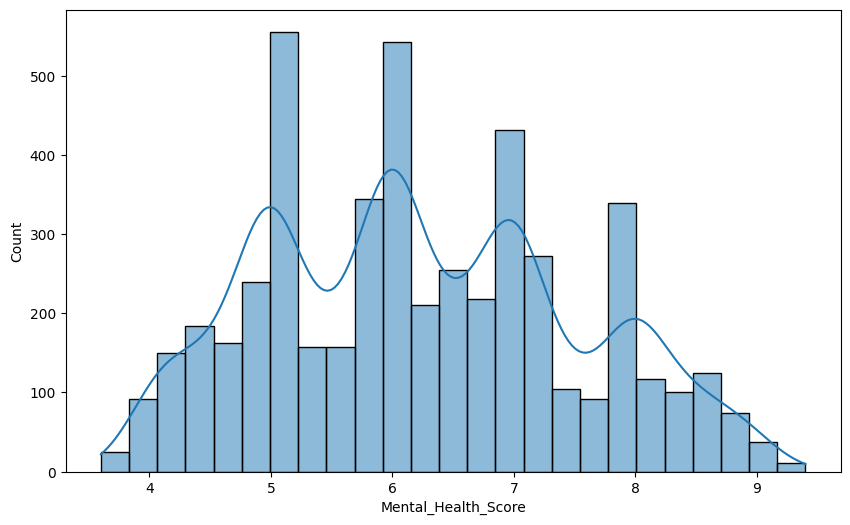

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

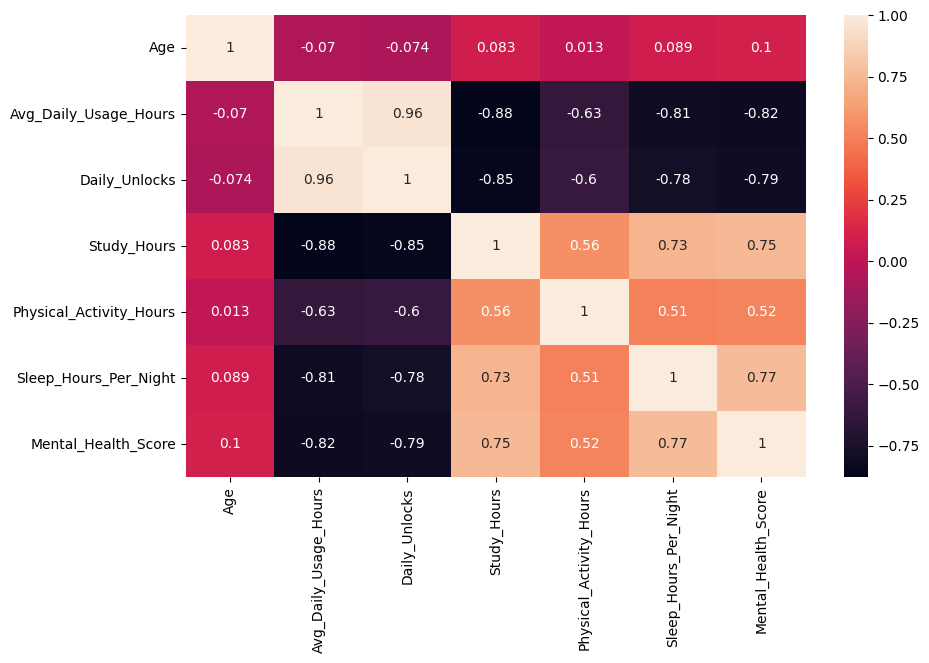

In [11]:
plt.figure(figsize=(10,6))
corr=df.corr(numeric_only=True)
sns.heatmap(data=corr,annot=True)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

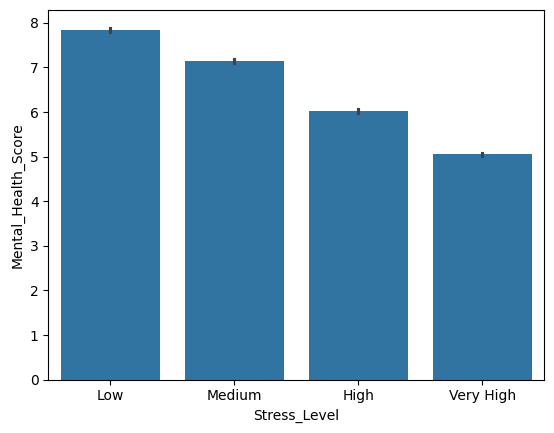

In [12]:
order=['Low','Medium','High','Very High']
sns.barplot(x=df['Stress_Level'],y=df['Mental_Health_Score'],order=order)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

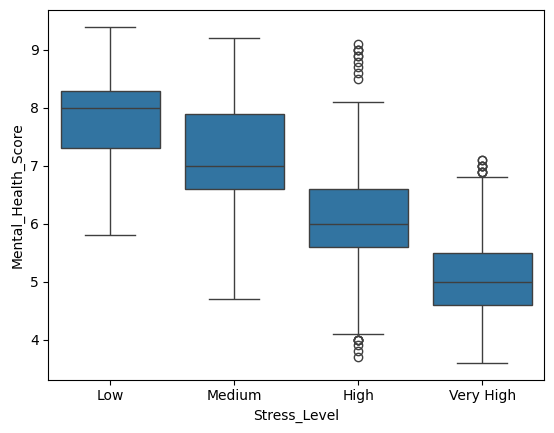

In [13]:
order=['Low','Medium','High','Very High']
sns.boxplot(x=df['Stress_Level'],y=df['Mental_Health_Score'],order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

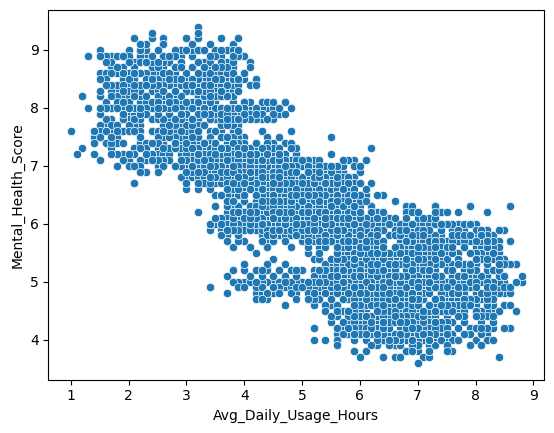

In [14]:
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

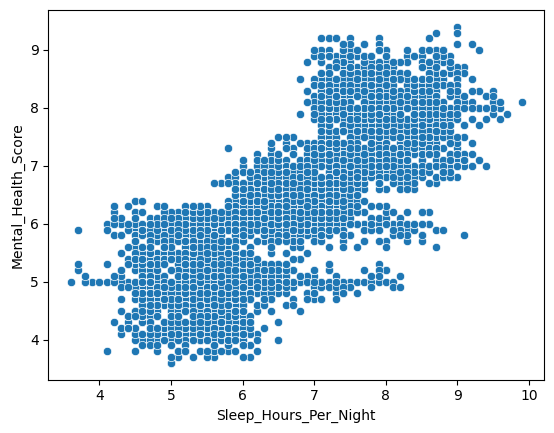

In [15]:
sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data=df)

In [16]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

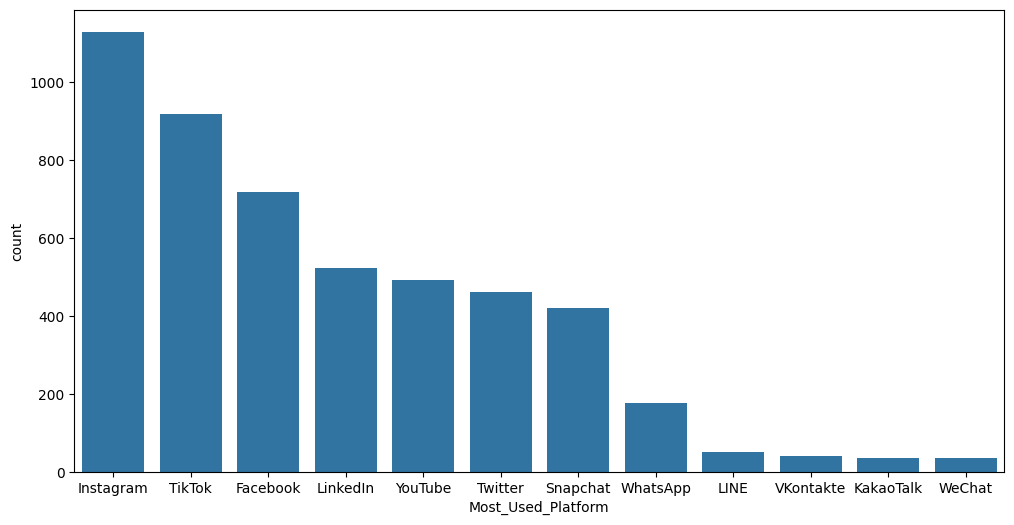

In [17]:
plt.figure(figsize=(12,6))
sns.countplot(x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)

**Outlier** Detection

In [18]:
numeric_features=df.select_dtypes(include='number')
Q1=numeric_features.quantile(0.25)
Q3=numeric_features.quantile(0.75)


IQR=Q3-Q1
Upper_Bound= Q3+1.5*IQR
Lower_Bound= Q1-1.5*IQR

outliers = (numeric_features < Lower_Bound) | (numeric_features > Upper_Bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


Data Cleaning

In [19]:
df=df.drop_duplicates()
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [20]:
numeric_features.skew()

Age                        0.155325
Avg_Daily_Usage_Hours      0.005606
Daily_Unlocks              0.002351
Study_Hours                0.435819
Physical_Activity_Hours    0.039971
Sleep_Hours_Per_Night      0.124050
Mental_Health_Score        0.206567
dtype: float64

In [21]:
top_countries=df['Country'].value_counts().index[:10].tolist()
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'
df['Grouped_Country']=df['Country'].apply(group_countries)

In [22]:
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_Country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9,Other
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7,Other
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0,India
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7,Other


In [23]:
df['Grouped_Country'].value_counts()

Grouped_Country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [24]:
skewed_cols=['Study_Hours']
other_numeric_cols=['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ordinal_cols=['Stress_Level']
normal_cols=['Gender','Academic_Level','Grouped_Country','Most_Used_Platform','Purpose_Of_Use']

feature_cols=skewed_cols+other_numeric_cols+ordinal_cols+normal_cols
X=df[feature_cols]
y=df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.30, random_state=42)

NameError: name 'train_test_split' is not defined

# Building Pipeline for different Columns which needs Different Operations

In [ ]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split


In [ ]:
skewed_pipeline=Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
])
numeric_pipeline=Pipeline(steps=[
    ('scaler',StandardScaler())
    ])
ordinal_pipeline=Pipeline(steps=[
    ('ordinal_encoder',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])
normal_pipeline=Pipeline(steps=[
    ('one_hot_encoder',OneHotEncoder(drop='first',handle_unknown='ignore'))
])

In [ ]:
col_transform=ColumnTransformer(transformers=[
    ('Skewed Pipelin',skewed_pipeline,skewed_cols),
    ('Numeric Pipeline',numeric_pipeline,other_numeric_cols),
    ('Ordinal Pipeline',ordinal_pipeline,ordinal_cols),
    ('Normal Pipeline',normal_pipeline,normal_cols)
])

In [ ]:
col_transform

ColumnTransformer(transformers=[('Skewed Pipelin',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['Study_Hours']),
                                ('Numeric Pipeline',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('Ordinal Pipeline',
                                 Pipeline(steps=[('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('Normal Pipeline',
                                 Pipeline(steps=[('one_hot_encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level', 'Grouped_Country',
                                  'Most_Used_Platform', 'Purpose_Of_Use'])])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score ,mean_absolute_error

In [ ]:
lr_pipeline=Pipeline(steps=[
    ('col_transform',col_transform),
    ('linear regression',LinearRegression())
])
lr_pipeline.fit(X_train,y_train)
lr_pred_test=lr_pipeline.predict(X_test)
lr_pred_train=lr_pipeline.predict(X_train)


r2_score_test=r2_score(lr_pred_test,y_test)
r2_score_train=r2_score(lr_pred_train,y_train)
print(r2_score_test)
print(r2_score_train)

lr_mae=mean_absolute_error(lr_pred_test,y_test)

lr_mse=mean_squared_error(lr_pred_test,y_test)

print(lr_mae)
print(lr_mse)

0.6200242018205973
0.6181682791289143
0.5361775634720183
0.45701905273488


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_pipeline=Pipeline(steps=[
    ('col_transform',col_transform),
    ('random forest',RandomForestRegressor(random_state=42))
])
rf_pipeline.fit(X_train,y_train)
rf_pred_test=rf_pipeline.predict(X_test)
rf_pred_train=rf_pipeline.predict(X_train)

In [ ]:
r2_score_test=r2_score(rf_pred_test,y_test)
r2_score_train=r2_score(rf_pred_train,y_train)
print(r2_score_test)
print(r2_score_train)

rf_mae=mean_absolute_error(rf_pred_test,y_test)

rf_mse=mean_squared_error(rf_pred_test,y_test)

print('rf_mae',lr_mae)
print('rf_mse',lr_mse)

0.8483144663093567
0.9786190677548214
rf_mae 0.5361775634720183
rf_mse 0.45701905273488


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grids={

        'random forest__n_estimators':[100,200,300],
        'random forest__max_depth':[None,5,10,20],
        'random forest__min_samples_split':[2,5,10],
        'random forest__min_samples_leaf':[1,2,4]

}
random_search=RandomizedSearchCV(estimator=rf_pipeline,param_distributions=param_grids,cv=5,n_iter=15,scoring='r2',verbose=2,n_jobs=-1)
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('col_transform',
                                              ColumnTransformer(transformers=[('Skewed '
                                                                               'Pipelin',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Numeric '
                                                                               'Pipeline',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unloc...
                                                                                'Grouped_Country',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use'])])),
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [None, 5,
                                                                     10, 20],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   scoring='r2', verbose=2)

In [ ]:
best_model=random_search.best_estimator_
best_model

Pipeline(steps=[('col_transform',
                 ColumnTransformer(transformers=[('Skewed Pipelin',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('Numeric Pipeline',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_H...
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('Normal Pipeline',
                                                  Pipeline(steps=[('one_hot_encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Grouped_Country',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use'])])),
                ('random forest',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [ ]:
best_model_pred=best_model.predict(X_test)


array([4.87433333, 5.57433333, 4.225     , ..., 6.01533333, 8.00333333,
       6.621     ])

In [ ]:
print(f'Best model R 2 score: {round(r2_score(y_test,best_model_pred),2)}')
print(f'Best model MAE score: {round(mean_squared_error(y_test,best_model_pred),2)}')

Best model R 2 score: 0.88
Best model MAE score: 0.22


In [ ]:
import joblib
joblib.dump(rf_pipeline,'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']

In [25]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'Grouped_Country']